# Read and understand data

In [1]:
import numpy as np
import pandas as pd

In [ ]:
# uplift_data = pd.read_csv("hf://datasets/criteo/criteo-uplift/criteo-research-uplift-v2.1.csv.gz", engine='pyarrow')
# from sklearn.model_selection import train_test_split

# sampled_df, _ = train_test_split(
#     uplift_data,
#     train_size=0.01,
#     stratify=uplift_data["treatment"],
#     random_state=42
# )
# sampled_df.to_csv('criteo-uplift.csv',index=False)

c:\Users\bindu\anaconda3\envs\data_maths\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
uplift_data = pd.read_csv(r"criteo-uplift.csv", engine='pyarrow')

In [7]:
len(uplift_data)

139795

In [4]:
uplift_data.columns

Index(['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10',
       'f11', 'treatment', 'conversion', 'visit', 'exposure'],
      dtype='str')

In [5]:
# percentage of users under treatment
pct_treated = uplift_data['treatment'].mean()

print(f"> {pct_treated:.2%} of the users are subjected to treatment, data is highly imbalanced.")

> 85.00% of the users are subjected to treatment, data is highly imbalanced.


In [6]:
exp_trt_ratio = uplift_data.loc[uplift_data['treatment'] == 1, 'exposure'].mean()

print(f"> only {exp_trt_ratio:.2%} of the treated users are actually exposed to the ad, that means 36 out of every thousand users see the ad")

> only 3.61% of the treated users are actually exposed to the ad, that means 36 out of every thousand users see the ad


In [7]:
trtd_ad_visits = uplift_data.loc[uplift_data['treatment'] == 1, 'visit'].mean()

print(f"> Treated Users visiting ad - {trtd_ad_visits:.2%}")

> Treated Users visiting ad - 4.83%


OBSERVATION: 4.83% of treated users visit the site.

This 4.83% includes:
- Users whose ads loaded (exposure=1)
- Users whose ads failed (exposure=0)

WHY WE DON'T BREAK THIS DOWN BY EXPOSURE:
1. Exposure is NOT random → depends on engagement, device, internet speed
2. These factors also affect conversion independently → confounding
3. Comparing exposed vs not-exposed would mix:
   - True ad effect (what we want)
   - Selection bias from engagement (confounding)
   - Can't separate them without IV methods (out of scope)

THEREFORE:
- We use ITT: treatment assignment regardless of exposure status
- This gives the real-world campaign effect (including ~8% failures)
- It's causal because treatment was random (T ⊥⊥ X)

In [8]:
trtd_ad_visits = uplift_data.loc[(uplift_data['treatment'] == 1) & (uplift_data['exposure'] == 0), 'visit'].mean()

print(f"Treated Users visiting ad - {trtd_ad_visits:.2%}")

Treated Users visiting ad - 3.47%


In [28]:
uplift_data.loc[(uplift_data['treatment'] == 0) & (uplift_data['exposure'] == 0), 'visit'].value_counts()

visit
0.0    2016832
1.0      80105
Name: count, dtype: int64

In [ ]:
# treated with ad, ad is exposed, visited the website, is converted ?
uplift_data.loc[(uplift_data['treatment'] == 1) & (uplift_data['exposure'] == 1) & (uplift_data['visit'] == 1), 'conversion'].value_counts()

conversion
0.0    151365
1.0     22807
Name: count, dtype: int64

In [ ]:
# treated with ad, ad is exposed, not visited thw website, no conversion
uplift_data.loc[(uplift_data['treatment'] == 1) & (uplift_data['exposure'] == 1) & (uplift_data['visit'] == 0), 'conversion'].value_counts()

conversion
0.0    245890
Name: count, dtype: int64

In [ ]:
# treated with ad, ad isn't exposed, visited the website (via other streams like direct visit, email, returning customer), 
# is converted (but not because of ad) ?
uplift_data.loc[(uplift_data['treatment'] == 1) & (uplift_data['exposure'] == 0) & (uplift_data['visit'] == 1), 'conversion'].value_counts()

conversion
0.0    376819
1.0     13514
Name: count, dtype: int64

In [ ]:
# treated with ad, ad isn't exposed, not visited the website, no conversion
uplift_data.loc[(uplift_data['treatment'] == 1) & (uplift_data['exposure'] == 0) & (uplift_data['visit'] == 0), 'conversion'].value_counts()

conversion
0.0    10915334
Name: count, dtype: int64

In [ ]:
# not treated with ad, ad isn't exposed, visited the website (via other streams like direct visit, email, returning customer), 
# is converted (but not because of ad) ?
uplift_data.loc[(uplift_data['treatment'] == 0) & (uplift_data['exposure'] == 0) & (uplift_data['visit'] == 1), 'conversion'].value_counts()

conversion
0.0    76042
1.0     4063
Name: count, dtype: int64

In [ ]:
# not treated with ad, ad isn't exposed, not visited the website, no conversion
uplift_data.loc[(uplift_data['treatment'] == 0) & (uplift_data['exposure'] == 0) & (uplift_data['visit'] == 0), 'conversion'].value_counts()

conversion
0.0    2016832
Name: count, dtype: int64

In [57]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
%matplotlib inline
from statsmodels.stats.proportion import proportions_ztest

In [42]:
# treated with ad, visited the website, is converted ? (Intent-to-Treat - ITT)
trt_sucs = uplift_data.loc[(uplift_data['treatment'] == 1) & (uplift_data['visit'] == 1)].reset_index(drop=True)

In [50]:
cntrl_sucs = uplift_data.loc[(uplift_data['treatment'] == 0) & (uplift_data['visit'] == 1)].reset_index(drop=True)

In [51]:
len(trt_sucs), len(cntrl_sucs)

(57434, 7971)

In [46]:
trt_sucs.describe()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
count,57434.000000,57434.000000,57434.000000,57434.000000,57434.000000,57434.000000,57434.000000,57434.000000,57434.000000,57434.000000,57434.000000,57434.000000,57434.0,57434.000000,57434.0,57434.000000
mean,16.351028,10.125850,8.406594,2.851865,10.755643,3.747223,-7.204288,5.626299,3.817155,31.628562,5.490700,-0.193222,1.0,0.063725,1.0,0.308685
std,4.253659,0.278325,0.187774,2.399002,0.986545,0.954563,6.592709,1.886078,0.060606,11.451455,0.345266,0.075761,0.0,0.244265,0.0,0.461955
min,12.616365,10.059654,8.214383,-6.471268,10.280525,-7.376572,-26.385293,4.833815,3.646339,13.190056,5.300375,-1.171058,1.0,0.000000,1.0,0.000000
25%,12.616365,10.059654,8.264591,1.267425,10.280525,4.115453,-12.497217,4.833815,3.773923,22.570329,5.300375,-0.168679,1.0,0.000000,1.0,0.000000
50%,14.347951,10.059654,8.336987,4.679882,10.280525,4.115453,-6.699321,4.833815,3.811048,32.395545,5.300375,-0.168679,1.0,0.000000,1.0,0.000000
75%,19.618842,10.059654,8.498596,4.679882,11.029584,4.115453,0.294443,4.833815,3.854508,40.227410,5.540464,-0.168679,1.0,0.000000,1.0,1.000000
max,26.743878,14.713993,9.051790,4.679882,19.639038,4.115453,0.294443,11.998182,3.971858,66.193483,6.473904,-0.168679,1.0,1.000000,1.0,1.000000


(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5]),
 [Text(0, 0.5, 'f0'),
  Text(0, 1.5, 'f1'),
  Text(0, 2.5, 'f2'),
  Text(0, 3.5, 'f3'),
  Text(0, 4.5, 'f4'),
  Text(0, 5.5, 'f5'),
  Text(0, 6.5, 'f6'),
  Text(0, 7.5, 'f7'),
  Text(0, 8.5, 'f8'),
  Text(0, 9.5, 'f9'),
  Text(0, 10.5, 'f10'),
  Text(0, 11.5, 'f11'),
  Text(0, 12.5, 'treatment'),
  Text(0, 13.5, 'conversion'),
  Text(0, 14.5, 'visit'),
  Text(0, 15.5, 'exposure')])

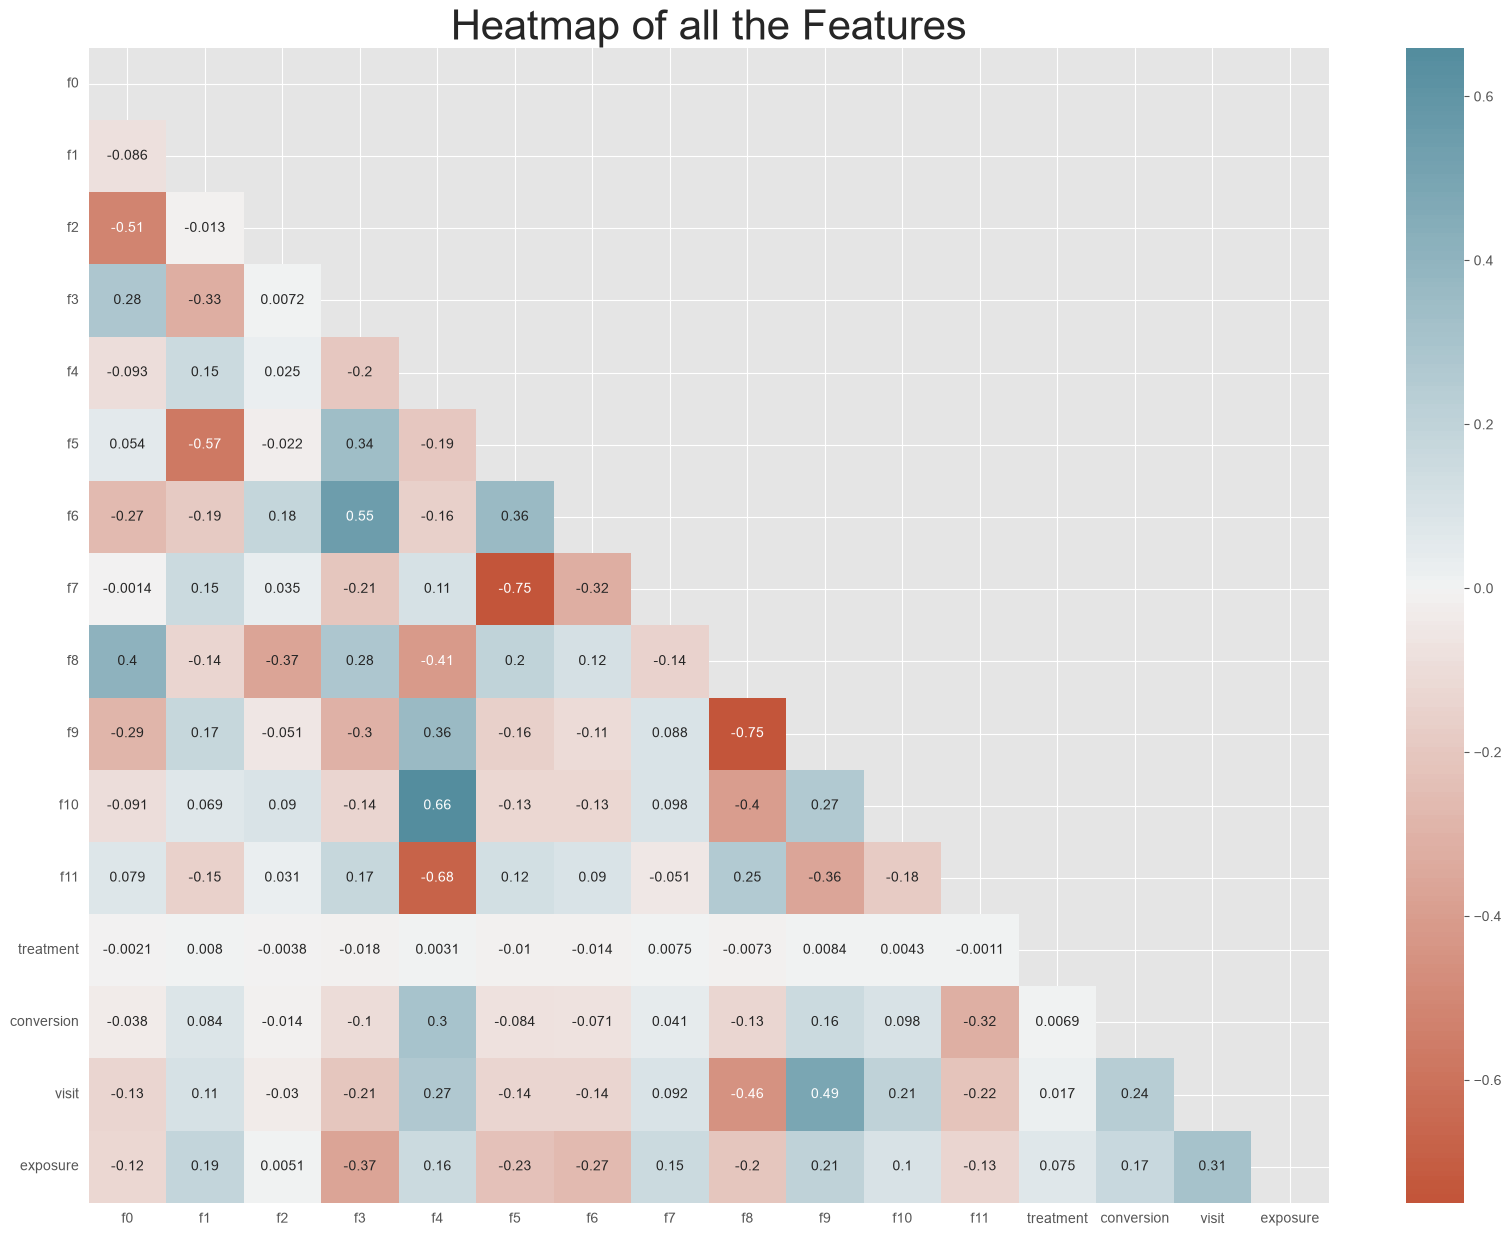

In [ ]:
# correlation between features
style.use('ggplot')
sns.set_style('whitegrid')
plt.subplots(figsize = (20,15))
## Plotting heatmap. 

# Generate a mask for the upper triangle (taken from seaborn example gallery)
mask = np.zeros_like(uplift_data.corr(), dtype=np.bool)
mask[np.triu_indices_from(mask)] = True


sns.heatmap(uplift_data.corr(), cmap=sns.diverging_palette(20, 220, n=200), annot=True, mask=mask, center = 0, )
plt.title("Heatmap of all the Features", fontsize = 30)
plt.yticks(rotation=0)

### Randomness check

In [32]:
covariates = [f"f{i}" for i in range(12)]

balance_table = (
    uplift_data.groupby("treatment")[covariates]
      .agg(['mean', 'std'])
      .T
)

print(balance_table)

treatment          0          1
f0  mean   19.649557  19.618379
    std     5.391047   5.375209
f1  mean   10.067900  10.070248
    std     0.093575   0.106235
f2  mean    8.449459   8.446255
    std     0.301341   0.299047
f3  mean    4.235477   4.169143
    std     1.235753   1.353206
f4  mean   10.336693  10.339657
    std     0.339188   0.345242
f5  mean    4.039193   4.026767
    std     0.397803   0.434839
f6  mean   -4.001345  -4.183870
    std     4.440549   4.599321
f7  mean    5.080735   5.106139
    std     1.165700   1.214617
f8  mean    3.934570   3.933416
    std     0.055414   0.056835
f9  mean   15.885520  16.050515
    std     6.799151   7.057363
f10 mean    5.331873   5.333928
    std     0.164504   0.169532
f11 mean   -0.170904  -0.170973
    std     0.022715   0.022722


In [33]:
from scipy.stats import ttest_ind
import pandas as pd

results = []

for col in covariates:
    treat = uplift_data.loc[uplift_data["treatment"] == 1, col]
    control = uplift_data.loc[uplift_data["treatment"] == 0, col]

    t_stat, p_val = ttest_ind(
        treat,
        control,
        equal_var=False,
        nan_policy="omit"
    )

    results.append({
        "feature": col,
        "t_stat": t_stat,
        "p_value": p_val,
        "treated_mean": treat.mean(),
        "control_mean": control.mean()
    })

ttest_results = pd.DataFrame(results)
print(ttest_results)

   feature     t_stat        p_value  treated_mean  control_mean
0       f0  -2.442649   1.458050e-02     19.618379     19.649557
1       f1  10.373323   3.310224e-25     10.070248     10.067900
2       f2  -4.494337   6.981412e-06      8.446255      8.449459
3       f3 -22.331381  2.246664e-110      4.169143      4.235477
4       f4   3.678902   2.342826e-04     10.339657     10.336693
5       f5 -12.999697   1.257705e-38      4.026767      4.039193
6       f6 -17.259493   1.024098e-66     -4.183870     -4.001345
7       f7   9.142040   6.165652e-20      5.106139      5.080735
8       f8  -8.760280   1.957723e-18      3.933416      3.934570
9       f9  10.186192   2.306753e-24     16.050515     15.885520
10     f10   5.250602   1.517084e-07      5.333928      5.331873
11     f11  -1.279430   2.007467e-01     -0.170973     -0.170904


In [34]:
import numpy as np

smd_results = []

for col in covariates:
    treat = uplift_data.loc[uplift_data["treatment"] == 1, col]
    control = uplift_data.loc[uplift_data["treatment"] == 0, col]

    pooled_sd = np.sqrt((treat.var(ddof=1) + control.var(ddof=1)) / 2)

    smd = (treat.mean() - control.mean()) / pooled_sd

    smd_results.append({
        "feature": col,
        "SMD": smd
    })

smd_results = pd.DataFrame(smd_results)
print(smd_results)

   feature       SMD
0       f0 -0.005792
1       f1  0.023460
2       f2 -0.010674
3       f3 -0.051191
4       f4  0.008660
5       f5 -0.029819
6       f6 -0.040376
7       f7  0.021340
8       f8 -0.020565
9       f9  0.023811
10     f10  0.012305
11     f11 -0.003030


In [35]:
balance = ttest_results.merge(smd_results, on="feature")

balance["balanced"] = balance["SMD"].abs() < 0.1

print(balance)

   feature     t_stat        p_value  treated_mean  control_mean       SMD  \
0       f0  -2.442649   1.458050e-02     19.618379     19.649557 -0.005792   
1       f1  10.373323   3.310224e-25     10.070248     10.067900  0.023460   
2       f2  -4.494337   6.981412e-06      8.446255      8.449459 -0.010674   
3       f3 -22.331381  2.246664e-110      4.169143      4.235477 -0.051191   
4       f4   3.678902   2.342826e-04     10.339657     10.336693  0.008660   
5       f5 -12.999697   1.257705e-38      4.026767      4.039193 -0.029819   
6       f6 -17.259493   1.024098e-66     -4.183870     -4.001345 -0.040376   
7       f7   9.142040   6.165652e-20      5.106139      5.080735  0.021340   
8       f8  -8.760280   1.957723e-18      3.933416      3.934570 -0.020565   
9       f9  10.186192   2.306753e-24     16.050515     15.885520  0.023811   
10     f10   5.250602   1.517084e-07      5.333928      5.331873  0.012305   
11     f11  -1.279430   2.007467e-01     -0.170973     -0.170904

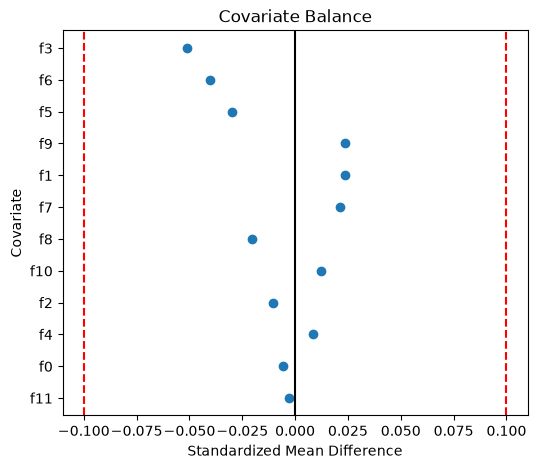

In [36]:
import matplotlib.pyplot as plt

plot_df = smd_results.sort_values("SMD", key=lambda x: x.abs())

plt.figure(figsize=(6,5))
plt.scatter(plot_df["SMD"], plot_df["feature"])

plt.axvline(0, color="black")
plt.axvline(0.1, color="red", linestyle="--")
plt.axvline(-0.1, color="red", linestyle="--")

plt.xlabel("Standardized Mean Difference")
plt.ylabel("Covariate")
plt.title("Covariate Balance")
plt.show()

# Average Treatment Effect

In [8]:
# Based on the condition, Users are randomly treated
avg_trt_c = uplift_data[uplift_data['treatment'] == 1]['conversion'].mean()
avg_cntrl_c = uplift_data[uplift_data['treatment'] == 0]['conversion'].mean()
print(f"Average treatment effect = {avg_trt_c - avg_cntrl_c}")

Average treatment effect = 0.001124866678065696


# Conditional Average Treatment Effect

## Learners

The Conditional Average Treatment Effect (CATE) is to find the expected uplift given covariates (X).

$\tau(x)=E[Y(1)-Y(0)\mid X=x].$

For an individual *i*,

$\tau(x_i)=E[D_i\mid X_i=x_i],$

where

$D_i=Y_i(1)-Y_i(0)$

is the **true individual treatment effect (ITE)**.

We cannot get to see the effect of individual with ($Y(1)$) and without treatment ($Y(0)$) both at once. Every meta-learner(S-, T-, X-, R-learner, etc.) tries to predict this to compute CATE estimate in it's own way.

Given training data $X_i$ and Target $D_i$, the objective is to solve - 

$\hat{\tau} = \arg\min_f\sum_i(D_i-f(X_i))^2.$

The optimal predictor is $f(x) = E[D|X=x] = \tau(x).$

So if we knew every individual's treatment effect, estimating CATE would be trivial.

In [ ]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
import numpy as np
from sklearn.base import clone
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklift.metrics import qini_auc_score, uplift_auc_score
from sklift.metrics import qini_curve, uplift_curve
import matplotlib.pyplot as plt


In [10]:
uplift_data.columns

Index(['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10',
       'f11', 'treatment', 'conversion', 'visit', 'exposure'],
      dtype='str')

In [11]:
feature_cols = [f"f{i}" for i in range(12)]

X = uplift_data[feature_cols]
T = uplift_data["treatment"]
Y = uplift_data["visit"] #["conversion"]

In [12]:
X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X,
    T,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=T
)

### T - Learner

In [ ]:
class TLearner:
    def __init__(self, model):
        self.model_treated = clone(model)
        self.model_control = clone(model)

    def fit(self, X, treatment, y):
        """
        Parameters
        ----------
        X : array-like (n_samples, n_features)
        treatment : binary array (0=control, 1=treated)
        y : outcome
        """

        treated_idx = treatment == 1
        control_idx = treatment == 0

        self.model_treated.fit(
            X[treated_idx],
            y[treated_idx]
        )

        self.model_control.fit(
            X[control_idx],
            y[control_idx]
        )

    def predict(self, X):
        """
        Returns estimated CATE.
        """

        if hasattr(self.model_treated, "predict_proba"):
            mu1 = self.model_treated.predict_proba(X)[:, 1]
            mu0 = self.model_control.predict_proba(X)[:, 1]
        else:
            mu1 = self.model_treated.predict(X)
            mu0 = self.model_control.predict(X)

        return mu1 - mu0

    def predict_outcomes(self, X):
        """
        Returns predicted treated and control outcomes.
        """
        if hasattr(self.model_treated, "predict_proba"):
            mu1 = self.model_treated.predict_proba(X)[:, 1]
            mu0 = self.model_control.predict_proba(X)[:, 1]
        else:
            mu1 = self.model_treated.predict(X)
            mu0 = self.model_control.predict(X)

        return mu1, mu0

In [36]:

# X = features
# T = treatment (0/1)
# Y = binary outcome

X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X,
    T,
    Y,
    test_size=0.2,
    random_state=42
)

base_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

tlearner = TLearner(base_model)

tlearner.fit(X_train, T_train, Y_train)

uplift_t = tlearner.predict(X_test)

print(uplift_t[:10])

[-1.1606426e-03  4.8124902e-03  3.3027856e-03  3.1884164e-02
 -5.3803250e-04  1.0474597e-04 -4.8013931e-04  1.3535472e-02
  4.6655303e-05 -7.6344818e-02]


In [ ]:
qini = qini_auc_score(
    y_true=Y_test,
    uplift=uplift_t,
    treatment=T_test
)

auuc = uplift_auc_score(
    y_true=Y_test,
    uplift=uplift_t,
    treatment=T_test
)

print("Qini :", qini)
print("AUUC  :", auuc)

Qini : 0.1160892185817765
AUUC  : 0.04614581237826449


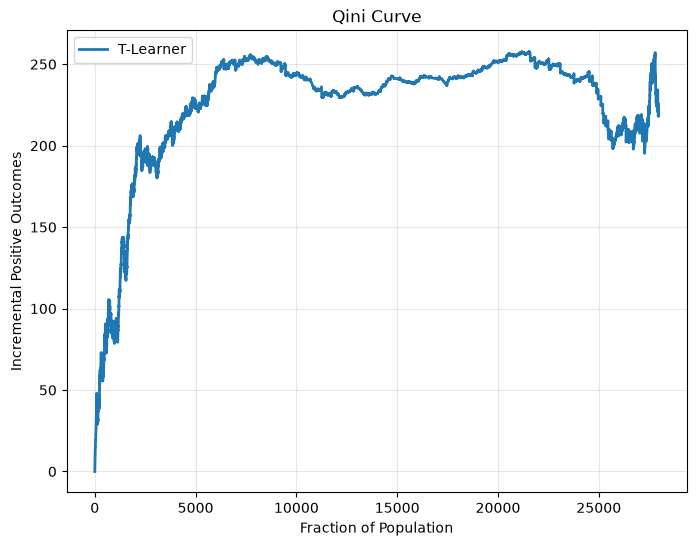

In [37]:
# Qini
x_qini, y_qini = qini_curve(Y_test, uplift_t, T_test)

plt.figure(figsize=(8,6))
plt.plot(x_qini, y_qini, lw=2, label='T-Learner')
plt.xlabel("Fraction of Population")
plt.ylabel("Incremental Positive Outcomes")
plt.title("Qini Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

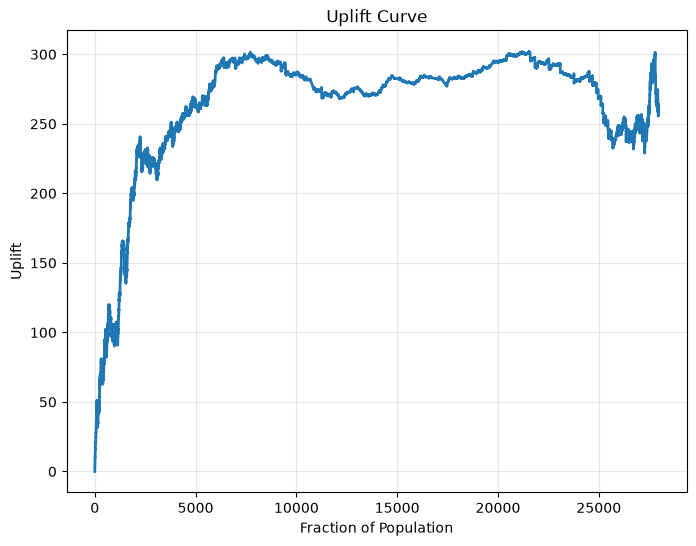

In [38]:
# Uplift Curve
x_uplift, y_uplift = uplift_curve(Y_test, uplift_t, T_test)

plt.figure(figsize=(8,6))
plt.plot(x_uplift, y_uplift, lw=2)
plt.xlabel("Fraction of Population")
plt.ylabel("Uplift")
plt.title("Uplift Curve")
plt.grid(alpha=0.3)
plt.show()

### X - learner

X-learner solves this by *Estimating the missing potential outcome first.*

Construct pseudo treatment effects from two outcome models - 
$\mu_1(x)=E[Y|T=1,X=x]$ and $\mu_0(x)=E[Y|T=0,X=x].$

For treated units - 

Observed $Y(1)$, Estimated $\hat{\mu}_0(x)$.

So estimate $D_i = Y(1)-Y(0)$ becomes

$\boxed{\tilde D_i^{(1)} = Y_i-\hat{\mu}_0(X_i)}$

For control units -

Observed $Y(0)$, Estimated $\hat{\mu}_1(x)$.

So estimate $D_i = Y(1)-Y(0)$ becomes

$\boxed{\tilde D_i^{(0)} = \hat{\mu}_1(X_i)-Y_i}$

These are called **imputed treatment effects** or **pseudo-treatment effects**.

Now we turn this into a supervised learning problem. Instead of

| X     | Unknown target |
| ----- | -------------- |
| $X_i$ | $D_i$          |

we use

| X     | Approximate target |
| ----- | ------------------ |
| $X_i$ | $\tilde D_i$       |

to train regression model

$g(x)$ by minimizing $\sum_i(\tilde D_i-g(X_i))^2.$

Thus $\hat{\tau}(x)=g(x).$

---

#### How does this minimize the CATE MSE?

$E[(D-\hat\tau)^2] = E[(D-\tau)^2] + E[(\tau-\hat\tau)^2].$

The first term, $E[(D-\tau)^2] = \operatorname{Var}(D|X)$, is determined by nature. No algorithm can reduce it.

Therefore, among all estimators, $\arg\min_{\hat\tau}E[(D-\hat\tau)^2] = \arg\min_{\hat\tau}E[(\tau-\hat\tau)^2].$


So if our pseudo-treatment effects $\tilde D$ are good approximations of the true $D$, then fitting a regression model to $\tilde D$ approximately minimizes the desired CATE MSE.

---

#### Why two regressions instead of one?

Instead of pooling all pseudo-effects together, it fits

* one model on treated units: $\tau_1(x)$
* one model on control units: $\tau_0(x)$

and combines them using the propensity score: $\boxed{\hat\tau(x) = g(x)\hat\tau_0(x)+(1-g(x))\hat\tau_1(x),}$ where $g(x)=P(T=1\mid X=x).$

This weighting gives more influence to the group that provides a more reliable estimate of the treatment effect at that $x$. For example, if treated observations are scarce for a region of the feature space, the control-based estimate may be more stable there, and vice versa.

So the overall strategy of the X-learner is:

1. Estimate the outcome functions $\mu_0(x)$ and $\mu_1(x)$.
2. Use them to impute individual treatment effects $\tilde D$.
3. Learn a regression from $X$ to these pseudo-treatment effects.
4. Combine the treated- and control-based regressions to produce the final CATE estimate.


In [16]:
mu1 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

mu1.fit(
    X_train[T_train == 1],
    Y_train[T_train == 1]
)

[LightGBM] [Info] Number of positive: 4594, number of negative: 90383
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1683
[LightGBM] [Info] Number of data points in the train set: 94977, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048370 -> initscore=-2.979305
[LightGBM] [Info] Start training from score -2.979305
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

LGBMClassifier(learning_rate=0.05, max_depth=6, n_estimators=300,
               random_state=42)

In [17]:
mu0 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

mu0.fit(
    X_train[T_train == 0],
    Y_train[T_train == 0]
)

[LightGBM] [Info] Number of positive: 656, number of negative: 16203
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001015 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1614
[LightGBM] [Info] Number of data points in the train set: 16859, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038911 -> initscore=-3.206791
[LightGBM] [Info] Start training from score -3.206791
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

LGBMClassifier(learning_rate=0.05, max_depth=6, n_estimators=300,
               random_state=42)

In [18]:
treated = T_train == 1

D1 = (
    Y_train[treated]
    - mu0.predict_proba(X_train[treated])[:,1]
)

In [19]:
control = T_train == 0

D0 = (
    mu1.predict_proba(X_train[control])[:,1]
    - Y_train[control]
)

In [20]:
tau1 = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

tau0 = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

tau1.fit(X_train[treated], D1)
tau0.fit(X_train[control], D0)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1683
[LightGBM] [Info] Number of data points in the train set: 94977, number of used features: 12
[LightGBM] [Info] Start training from score 0.007874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1614
[LightGBM] [Info] Number of data points in the train set: 16859, number of used features: 12
[LightGBM] [Info] Start training from score 0.004262


LGBMRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [21]:
g = LGBMClassifier(
    n_estimators=200,
    random_state=42
)

g.fit(X_train, T_train)

propensity = g.predict_proba(X_test)[:,1]

[LightGBM] [Info] Number of positive: 94977, number of negative: 16859
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1687
[LightGBM] [Info] Number of data points in the train set: 111836, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.849252 -> initscore=1.728750
[LightGBM] [Info] Start training from score 1.728750


In [22]:
tau1_pred = tau1.predict(X_test)
tau0_pred = tau0.predict(X_test)

In [23]:
uplift_x = propensity * tau0_pred + (1 - propensity) * tau1_pred

In [24]:
uplift_x

array([ 1.32839783e-03,  2.58094161e-02,  8.08285989e-04, ...,
       -9.58594992e-05, -1.46139386e-02, -3.07918690e-04], shape=(27959,))

This can be done through EconML library as well importing XLearner directly.

In [25]:
from econml.metalearners import XLearner
from lightgbm import LGBMRegressor
from sklearn.linear_model import LogisticRegression

x_learner = XLearner(
    models=LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),
    cate_models=LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),
    propensity_model=LogisticRegression(max_iter=1000)
)

x_learner.fit(
    Y=Y_train,
    T=T_train,
    X=X_train
)

uplift_x_ml = x_learner.effect(X_test)

c:\Users\bindu\anaconda3\envs\data_maths\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1614
[LightGBM] [Info] Number of data points in the train set: 16859, number of used features: 12
[LightGBM] [Info] Start training from score 0.038911
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1683
[LightGBM] [Info] Number of data points in the train set: 94977, number of used features: 12
[LightGBM] [Info] Start training from score 0.048370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000907 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

c:\Users\bindu\anaconda3\envs\data_maths\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\bindu\anaconda3\envs\data_maths\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
qini = qini_auc_score(
    Y_test,
    uplift_x,
    T_test
)

auuc = uplift_auc_score(
    Y_test,
    uplift_x,
    T_test
)

print("Qini:", qini)
print("AUUC :", auuc)

Qini: 0.07461698541302958
AUUC : 0.029584496516407346


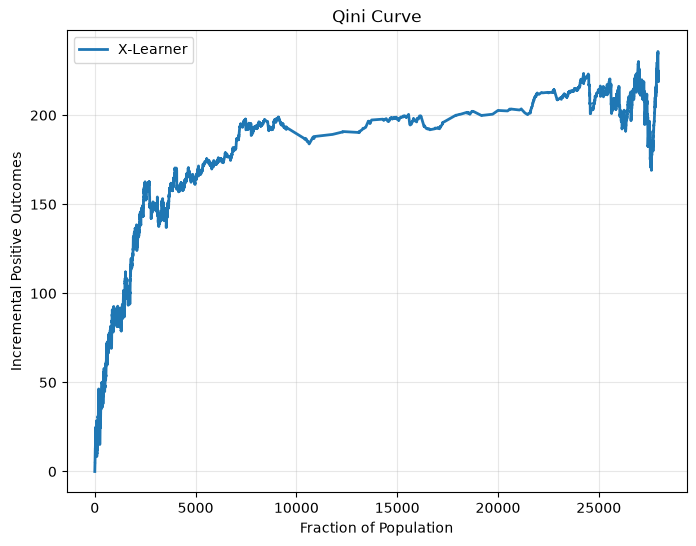

In [ ]:
# Qini
x_qini, y_qini = qini_curve(Y_test, uplift_x, T_test)

plt.figure(figsize=(8,6))
plt.plot(x_qini, y_qini, lw=2, label='X-Learner')
plt.xlabel("Fraction of Population")
plt.ylabel("Incremental Positive Outcomes")
plt.title("Qini Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

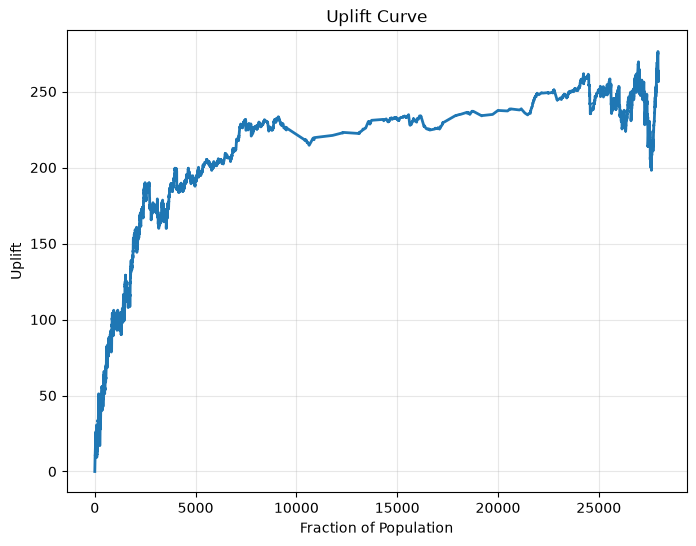

In [28]:
# Uplift Curve
x_uplift, y_uplift = uplift_curve(Y_test, uplift_x, T_test)

plt.figure(figsize=(8,6))
plt.plot(x_uplift, y_uplift, lw=2)
plt.xlabel("Fraction of Population")
plt.ylabel("Uplift")
plt.title("Uplift Curve")
plt.grid(alpha=0.3)
plt.show()

### R - learner

Rewrites the observed outcome with nuisance functions, that are basically residuals seen when computing treatment-effect signal.

Structural model $Y_i = m(X_i)+{W_i-e(X_i)}\tau(X_i)+\varepsilon_i.$

Nuisance functions are $m(x)=E[Y\mid X=x]$ and $e(x)=P(W=1\mid X=x).$

If treatment assignment is unconfounded, then $Y_i-m(X_i) = {W_i-e(X_i)}\tau(X_i)+\varepsilon_i$, where $E[\varepsilon_i\mid X_i,W_i]=0.$

This is called **Robinson's transformation** or **residualization**. It removes the main effect of the covariates, leaving only the treatment-effect signal plus noise.

Before residualization, $Y = \underbrace{m(X)}*{\text{large prediction}} + \underbrace{\tau(X)W}*{\text{small signal}}.$

After residualization, $Y-m(X) = (W-e(X))\tau(X).$

The nuisance function $m(X)$ disappears entirely.

Compare this with ordinary linear regression.

Normally, $y=x\beta+\epsilon.$

Here, $Y_i-m(X_i) = (W_i-e(X_i))\tau(X_i)+\epsilon_i.$

The natural least-squares objective is $\boxed{L(\tau) =
\frac1n\sum_{i=1}^n\left[(Y_i-m(X_i)) - (W_i-e(X_i))\tau(X_i)
\right]^2}$

Since $m$ and $e$ are unknown, they are replaced with cross-fitted estimates: $\hat m(X),\hat e(X)$

Finally objective becomes -

$\boxed{\hat L(\tau) = \frac1n\sum\left[(Y_i-\hat m(X_i)) -
(W_i-\hat e(X_i))\tau(X_i)\right]^2.}$


R-learner never constructs pseudo treatment effects unlike X-learner. Instead, it asks:

> *What value of $\tau(X)$ best explains the residualized outcome using the residualized treatment?*

So it directly solves a residual-on-residual regression.

In [48]:
from sklearn.model_selection import StratifiedKFold

class RLearner:

    def __init__(self,
                 outcome_model,
                 propensity_model,
                 effect_model,
                 n_splits=5,
                 random_state=42):

        self.outcome_model = clone(outcome_model)
        self.propensity_model = clone(propensity_model)
        self.effect_model = clone(effect_model)

        self.n_splits = n_splits
        self.random_state = random_state

    def fit(self, X, W, Y):

        X = np.asarray(X)
        W = np.asarray(W)
        Y = np.asarray(Y)

        n = len(Y)

        # Out-of-fold predictions
        m_hat = np.zeros(n)
        e_hat = np.zeros(n)

        kf = StratifiedKFold(
            n_splits=self.n_splits,
            shuffle=True,
            random_state=self.random_state
        )

        for train_idx, val_idx in kf.split(X, W):

            X_train, X_val = X[train_idx], X[val_idx]
            Y_train = Y[train_idx]
            W_train = W[train_idx]

            # -------------------
            # Outcome model
            # -------------------
            outcome = clone(self.outcome_model)
            outcome.fit(X_train, Y_train)

            m_hat[val_idx] = outcome.predict(X_val)

            # -------------------
            # Propensity model
            # -------------------
            propensity = clone(self.propensity_model)
            propensity.fit(X_train, W_train)

            e_hat[val_idx] = propensity.predict_proba(X_val)[:, 1]

        # Avoid divide-by-zero
        e_hat = np.clip(e_hat, 1e-3, 1 - 1e-3)

        # -------------------
        # Residuals
        # -------------------
        Y_res = Y - m_hat
        W_res = W - e_hat

        pseudo_outcome = Y_res / W_res
        sample_weight = W_res ** 2

        # -------------------
        # Final effect model
        # -------------------
        self.effect_model.fit(
            X,
            pseudo_outcome,
            sample_weight=sample_weight
        )

        # -------------------
        # Refit nuisance models
        # (used later for new data if needed)
        # -------------------
        self.outcome_model.fit(X, Y)
        self.propensity_model.fit(X, W)

        return self

    def predict(self, X):
        return self.effect_model.predict(X)

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

rlearner = RLearner(

    outcome_model=RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    propensity_model=RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    effect_model=RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

)

rlearner.fit(X_train, T_train, Y_train)

uplift_r = rlearner.predict(X_test)

c:\Users\bindu\anaconda3\envs\data_maths\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [ ]:
qini = qini_auc_score(
    Y_test,
    uplift_r,
    T_test
)

auuc = uplift_auc_score(
    Y_test,
    uplift_r,
    T_test
)

print("Qini:", qini)
print("AUUC :", auuc)

Qini: 0.0021565297633106156
AUUC : 0.0008653654089073509


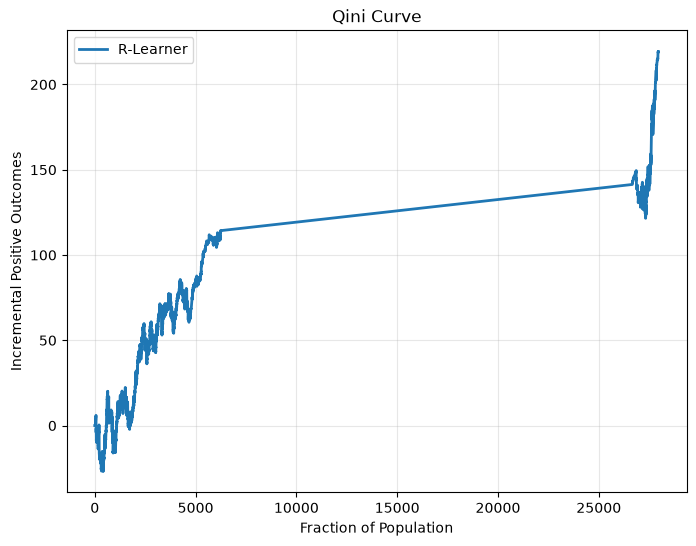

In [51]:
# Qini
x_qini, y_qini = qini_curve(Y_test, uplift_r, T_test)

plt.figure(figsize=(8,6))
plt.plot(x_qini, y_qini, lw=2, label='R-Learner')
plt.xlabel("Fraction of Population")
plt.ylabel("Incremental Positive Outcomes")
plt.title("Qini Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

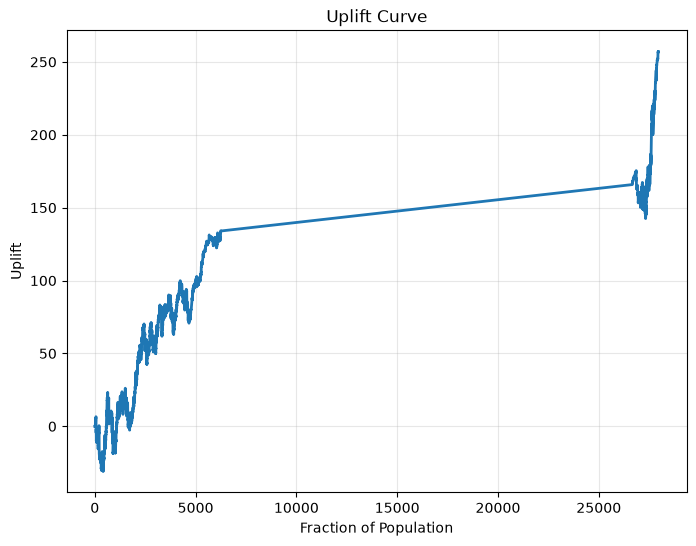

In [52]:
# Uplift Curve
x_uplift, y_uplift = uplift_curve(Y_test, uplift_r, T_test)

plt.figure(figsize=(8,6))
plt.plot(x_uplift, y_uplift, lw=2)
plt.xlabel("Fraction of Population")
plt.ylabel("Uplift")
plt.title("Uplift Curve")
plt.grid(alpha=0.3)
plt.show()

## Tree based

### Causal GBM (XGBoost)

In [32]:
from econml.dml import CausalForestDML
from xgboost import XGBRegressor, XGBClassifier

cf = CausalForestDML(
    model_y=XGBRegressor(
        n_estimators=30,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    ),
    model_t=XGBClassifier(
        n_estimators=30,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    ),
    n_estimators=40,
    random_state=42,
    discrete_treatment=True
)

cf.fit(
    Y_train,
    T_train,
    X=X_train
)

In [41]:
uplift_gbm = cf.effect(X_test)

In [ ]:
qini = qini_auc_score(
    Y_test,
    uplift_gbm,
    T_test
)

auuc = uplift_auc_score(
    Y_test,
    uplift_gbm,
    T_test
)

print(f"Qini : {qini:.4f}")
print(f"AUUC  : {auuc:.4f}")

Qini : 0.0593
AUUC  : 0.0234


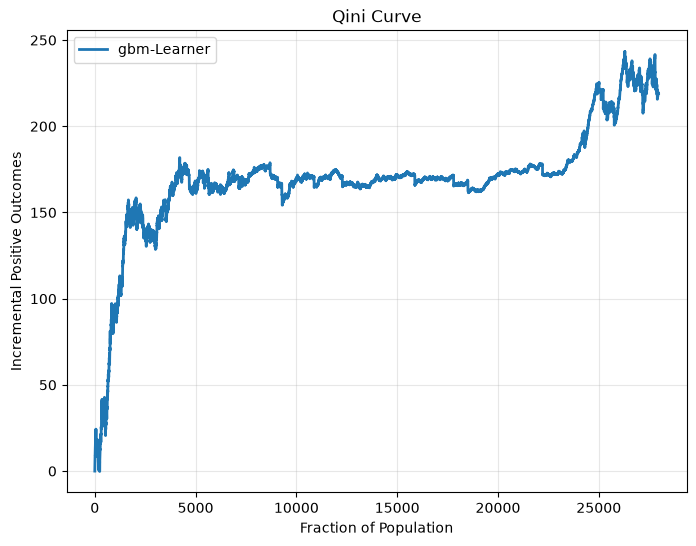

In [43]:
from sklift.metrics import qini_curve, uplift_curve
import matplotlib.pyplot as plt

# Qini
x_qini, y_qini = qini_curve(Y_test, uplift_gbm, T_test)

plt.figure(figsize=(8,6))
plt.plot(x_qini, y_qini, lw=2, label='gbm-Learner')
plt.xlabel("Fraction of Population")
plt.ylabel("Incremental Positive Outcomes")
plt.title("Qini Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

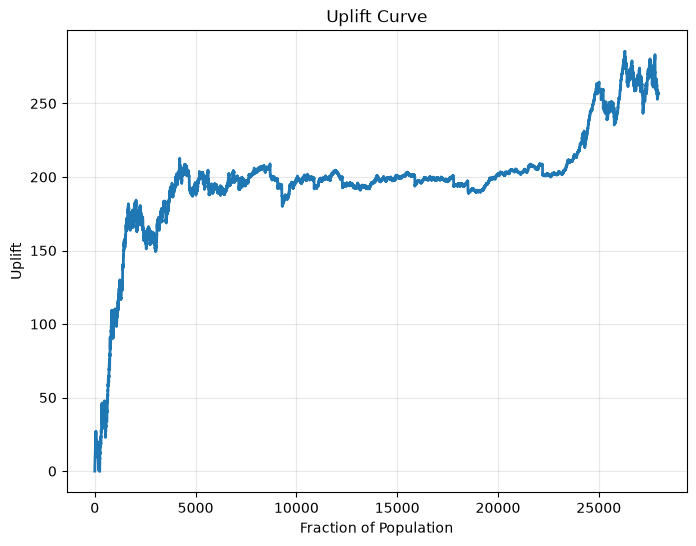

In [44]:
# Uplift Curve
x_uplift, y_uplift = uplift_curve(Y_test, uplift_gbm, T_test)

plt.figure(figsize=(8,6))
plt.plot(x_uplift, y_uplift, lw=2, label='gbm-Learner')
plt.xlabel("Fraction of Population")
plt.ylabel("Uplift")
plt.title("Uplift Curve")
plt.grid(alpha=0.3)
plt.show()

# Compare Models performance

In [53]:
def compute_metrics(y_true, uplift, treatment):
    qini = qini_auc_score(
        y_true=y_true,
        uplift=uplift,
        treatment=treatment
    )

    auuc = uplift_auc_score(
        y_true=y_true,
        uplift=uplift,
        treatment=treatment
    )

    x_qini, y_qini = qini_curve(y_true, uplift, treatment)
    x_uplift, y_uplift = uplift_curve(y_true, uplift, treatment)

    return qini, auuc, x_qini, y_qini, x_uplift, y_uplift

In [54]:
t_metrics = compute_metrics(Y_test, uplift_t, T_test)
x_metrics = compute_metrics(Y_test, uplift_x, T_test)
r_metrics = compute_metrics(Y_test, uplift_r, T_test)
gbm_metrics = compute_metrics(Y_test, uplift_gbm, T_test)

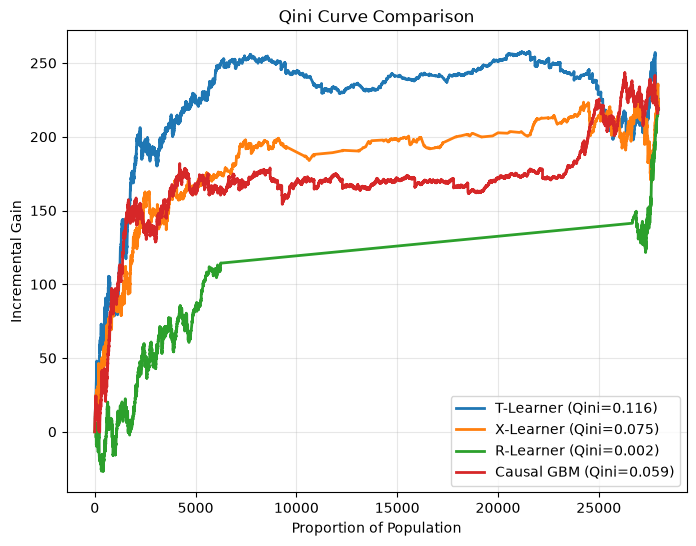

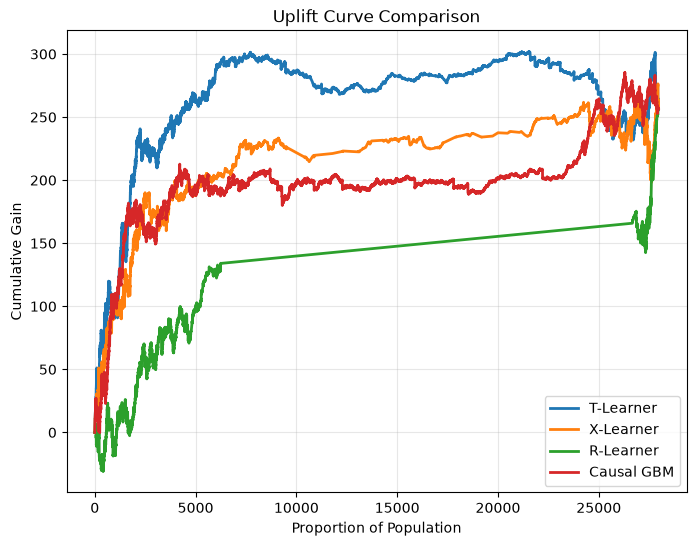

        Model      Qini      AUUC
0   T-Learner  0.116089  0.046146
1   X-Learner  0.074617  0.029584
3  Causal GBM  0.059318  0.023434
2   R-Learner  0.002157  0.000865


In [58]:
models = {
    "T-Learner": t_metrics,
    "X-Learner": x_metrics,
    "R-Learner": r_metrics,
    "Causal GBM": gbm_metrics
}

summary = []

# Qini comparison
plt.figure(figsize=(8,6))

for name, metrics in models.items():
    qini, auuc, x_qini, y_qini, x_uplift, y_uplift = metrics

    plt.plot(
        x_qini,
        y_qini,
        linewidth=2,
        label=f"{name} (Qini={qini:.3f})"
    )

    summary.append({
        "Model": name,
        "Qini": qini,
        "AUUC": auuc
    })

plt.xlabel("Proportion of Population")
plt.ylabel("Incremental Gain")
plt.title("Qini Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Uplift comparison
plt.figure(figsize=(8,6))

for name, metrics in models.items():

    _, _, _, _, x_uplift, y_uplift = metrics

    plt.plot(
        x_uplift,
        y_uplift,
        linewidth=2,
        label=name
    )

plt.xlabel("Proportion of Population")
plt.ylabel("Cumulative Gain")
plt.title("Uplift Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Summary table
summary = pd.DataFrame(summary)
summary = summary.sort_values("AUUC", ascending=False)

print(summary)